# 解說
這一篇承襲20260318_code資料夾裡的 "OU_LossIndecator-2D Spiral_betaSigmaConst" 這一篇。  
找到具體例子驗證:  
* $I_{DSM}$ 小 $\Rightarrow$ 圖好  
* $I_{DSM}$ 大 $\Rightarrow$ 圖差  
  
針對這個例題，我們將以五組beta以及其對應的t去做比較loss與$I_{DSM}$的結果

# Model

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [14]:
# --- 定義五組實驗參數 ---
beta_list = [0.1, 0.5, 1.0, 2.0, 5.0]
target_constant = 10.0
sigma = 5.0  # 保持固定

# 建立一個字典來存儲每一組對應的 T (時間終點)
configs = {b: target_constant / b for b in beta_list}

# 原本的 mu_t, std_t 建議寫成函數，方便在訓練迴圈中調用
def get_diffused_sample(x0, t, beta, sigma):
    # t 可以是一個 tensor (batch_size, 1)
    mu_t = np.exp(-beta * t) * x0
    var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    std_t = np.sqrt(var_t)
    eps = np.random.randn(*x0.shape)
    xt = mu_t + std_t * eps
    return xt, std_t, eps

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [18]:
def train(model, beta, sigma, T, steps, device):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    loss_his = []
    iDsm_his = []

    model.train() # 確保進入訓練模式
    for i in range(steps):
        # 1. 數據準備與搬移至 device
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32).to(device)
        
        # t 也要搬到 device
        t = (torch.rand(x0.shape[0]) * T).to(device)
        
        # 2. OU Process 前向擴散 (這裡使用 Tensor 運算)
        # 擴張維度以便與 x0 做 element-wise multiplication
        t_view = t.view(-1, 1) 
        mu_t = torch.exp(-beta * t_view) * x0
        
        # 計算 std_t (對應推導圖中的 sigma)
        var_t = (sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t_view))
        std_t = torch.sqrt(var_t)
        
        eps = torch.randn_like(x0).to(device)
        xt = mu_t + std_t * eps
        
        # 3. 訓練 Step
        optimizer.zero_grad()
        eps_pred = model(xt, t) # model(xt, t)
        
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        # 4. 計算 I_dsm indicator (核心修正點)
        with torch.no_grad():
            # 根據推導圖： <eps_theta, eps_theta - eps> / sigma_t^2
            inner_product = torch.sum(eps_pred * (eps_pred - eps), dim=1, keepdim=True)
            # 使用該時間點對應的方差 var_t 作為分母
            i_dsm_batch = torch.mean(inner_product / (var_t + 1e-7))

        loss_his.append(loss.item())
        iDsm_his.append(i_dsm_batch.item())
        
        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}, Idsm: {i_dsm_batch.item():.4f}")
            
    return loss_his, iDsm_his

# --- 呼叫區塊 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# --- 實驗參數設定 ---
beta_list = [0.1, 0.5, 1.0, 2.0, 5.0]
target_constant = 10.0  # beta * T = 10
steps = 5000            # 每個實驗跑 5000 step
sigma = 5.0

# 用來存五組實驗數據的字典
all_results = {}

# --- 開始實驗迴圈 ---
for i, b_val in enumerate(beta_list):
    # 自動根據條件計算 T
    T_val = target_constant / b_val
    
    print("==============================")
    print("==============================")
    print(f"\n[{i+1}/{len(beta_list)}] 正在實驗：Beta = {b_val}, T = {T_val:.2f}")
    
    # 每一組都要重新初始化模型，確保公平
    model = ScoreNet().to(device)
    
    # 呼叫你剛寫好的 train 函數
    loss_h, idsm_h = train(
        model=model, 
        beta=b_val, 
        sigma=sigma, 
        T=T_val, 
        steps=steps, 
        device=device
    )
    
    # 將結果連同 model 存起來 (model 轉回 cpu 避免 GPU 記憶體爆炸)
    all_results[b_val] = {
        "loss": loss_h,
        "idsm": idsm_h,
        "model": model.cpu(),
        "T": T_val
    }

print("\n✅ 所有實驗執行完畢！")


[1/5] 正在實驗：Beta = 0.1, T = 100.00
Step 0, Loss: 1.5068, Idsm: 0.0085
Step 100, Loss: 0.0380, Idsm: -0.0000
Step 200, Loss: 0.0396, Idsm: 0.0009
Step 300, Loss: 0.0366, Idsm: 0.0067
Step 400, Loss: 0.0459, Idsm: 0.0010
Step 500, Loss: 0.0404, Idsm: 0.0001
Step 600, Loss: 0.0342, Idsm: 0.0000
Step 700, Loss: 0.0410, Idsm: -0.0000
Step 800, Loss: 0.0383, Idsm: -0.0006
Step 900, Loss: 0.0418, Idsm: -0.0000
Step 1000, Loss: 0.0375, Idsm: -0.0000
Step 1100, Loss: 0.0445, Idsm: 0.0003
Step 1200, Loss: 0.0474, Idsm: 0.0001
Step 1300, Loss: 0.0394, Idsm: 0.0010
Step 1400, Loss: 0.0339, Idsm: -0.0002
Step 1500, Loss: 0.0394, Idsm: 0.0002
Step 1600, Loss: 0.0472, Idsm: 0.0001
Step 1700, Loss: 0.0397, Idsm: 0.0078
Step 1800, Loss: 0.0360, Idsm: 0.0001
Step 1900, Loss: 0.0405, Idsm: 0.0001
Step 2000, Loss: 0.0433, Idsm: 0.0001
Step 2100, Loss: 0.0460, Idsm: 0.0001
Step 2200, Loss: 0.0440, Idsm: 0.0001
Step 2300, Loss: 0.0386, Idsm: 0.0002
Step 2400, Loss: 0.0364, Idsm: -0.0009
Step 2500, Loss: 0.0

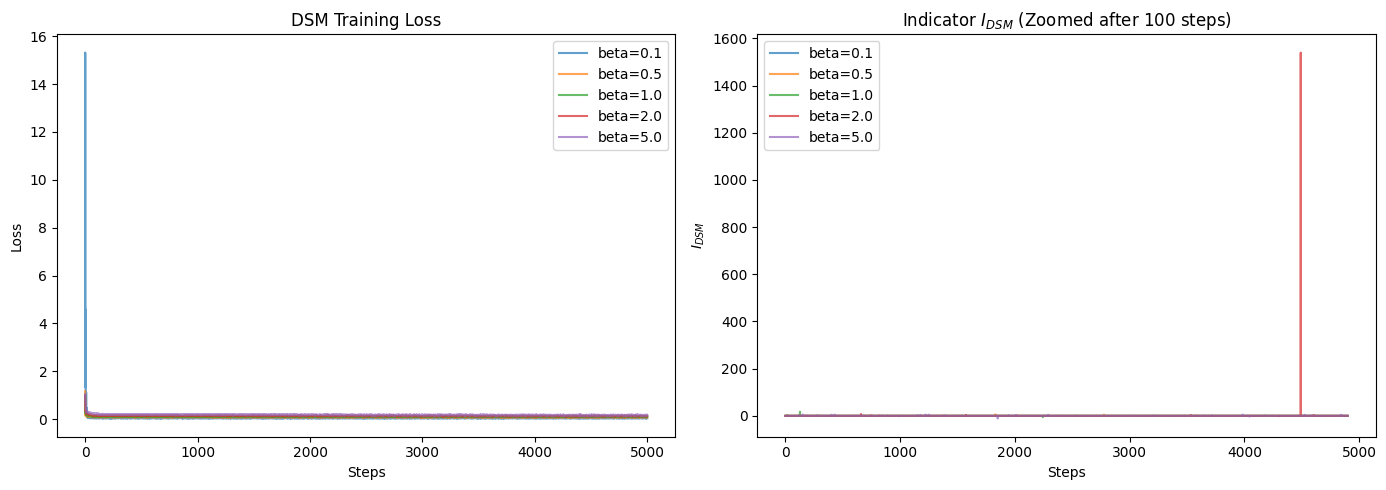

In [20]:
plt.figure(figsize=(14, 5))

# 1. 畫 Loss Curves
plt.subplot(1, 2, 1)
for b in beta_list:
    plt.plot(all_results[b]["loss"], label=f"beta={b}", alpha=0.7)
plt.title("DSM Training Loss")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.legend()

# 2. 畫 I_DSM Curves
plt.subplot(1, 2, 2)
for b in beta_list:
    # 因為 I_DSM 初期波動較大，可以用 [100:] 避開前期的極大值
    plt.plot(all_results[b]["idsm"][100:], label=f"beta={b}", alpha=0.7)
plt.title("Indicator $I_{DSM}$ (Zoomed after 100 steps)")
plt.xlabel("Steps"); plt.ylabel("$I_{DSM}$")
plt.legend()

plt.tight_layout()
plt.show()

# Reverse

---

In [22]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        eps_pred = model(x, t_tensor)
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        score = -eps_pred / (sigma_t + 1e-5)
        
        drift = -beta * x - (sigma**2) * score
        noise = torch.randn_like(x) if t_val > dt else 0
        
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x


>>> 實驗 1/5: Beta = 0.1, T = 100.00
Step 0, Loss: 1.7520, Idsm: 0.0098
Step 100, Loss: 0.0404, Idsm: -0.0001
Step 200, Loss: 0.0399, Idsm: 0.0004
Step 300, Loss: 0.0422, Idsm: 0.0001
Step 400, Loss: 0.0386, Idsm: 0.0001
Step 500, Loss: 0.0428, Idsm: 0.0001
Step 600, Loss: 0.0346, Idsm: 0.0001
Step 700, Loss: 0.0365, Idsm: -0.0001
Step 800, Loss: 0.0391, Idsm: 0.0019
Step 900, Loss: 0.0420, Idsm: 0.0000
Step 1000, Loss: 0.0407, Idsm: -0.0001
Step 1100, Loss: 0.0387, Idsm: 0.0004
Step 1200, Loss: 0.0460, Idsm: 0.0017
Step 1300, Loss: 0.0427, Idsm: -0.0003
Step 1400, Loss: 0.0400, Idsm: 0.0044
Step 1500, Loss: 0.0422, Idsm: -0.0000
Step 1600, Loss: 0.0364, Idsm: 0.0001
Step 1700, Loss: 0.0385, Idsm: 0.0006
Step 1800, Loss: 0.0404, Idsm: 0.0008
Step 1900, Loss: 0.0355, Idsm: -0.0000
Step 2000, Loss: 0.0452, Idsm: -0.0033
Step 2100, Loss: 0.0476, Idsm: 0.0006
Step 2200, Loss: 0.0446, Idsm: 0.0011
Step 2300, Loss: 0.0363, Idsm: -0.0000
Step 2400, Loss: 0.0436, Idsm: 0.0023

>>> 實驗 2/5: Beta 

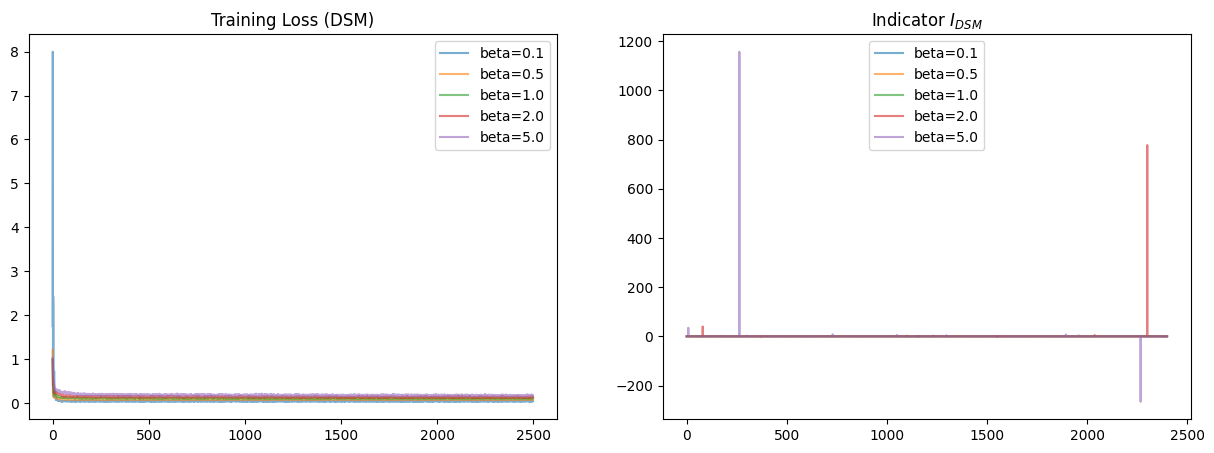

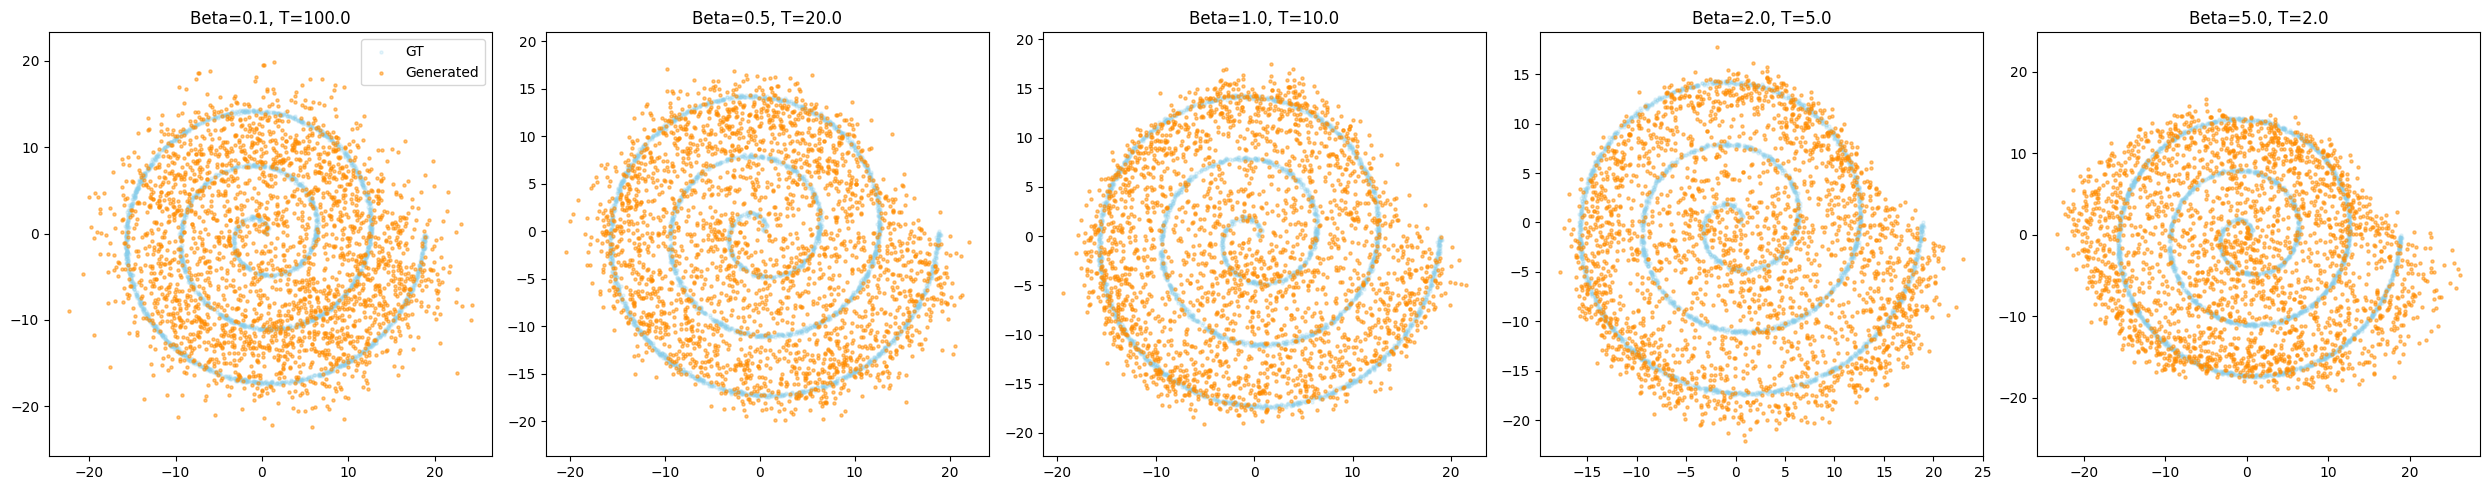

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. 參數設定
beta_list = [0.1, 0.5, 1.0, 2.0, 5.0]
target_constant = 10.0
sigma_val = 5.0  # 你的 sigma
train_steps = 2500
sampling_steps = 1000 # Reverse 採樣走 1000 步

# 儲存結果
all_results = {}
gt_data = sample_p0_mix(n_points=2500) # 準備一組 Ground Truth 用於疊圖

# 2. 開始五組 Beta 的實驗
for i, b_val in enumerate(beta_list):
    current_T = target_constant / b_val
    print(f"\n>>> 實驗 {i+1}/5: Beta = {b_val}, T = {current_T:.2f}")
    
    # 訓練模型
    model = ScoreNet().to(device)
    loss_h, idsm_h = train(model, beta=b_val, sigma=sigma_val, T=current_T, steps=train_steps, device=device)
    
    # 生成 Reverse 樣本
    # dt 設為 T / sampling_steps
    gen_samples = reverse_sample(
        model, n_samples=2500, beta=b_val, sigma=sigma_val, 
        T=current_T, dt=current_T/sampling_steps
    )
    
    # 存起來
    all_results[b_val] = {
        "loss": loss_h, 
        "idsm": idsm_h, 
        "gen_data": gen_samples.cpu().numpy(),
        "avg_loss": np.mean(loss_h),
        "avg_idsm": np.mean(idsm_h)
    }

# --- 繪圖區 ---

# 需求 1 & 2: Loss 與 IDSM 曲線 + 平均值輸出
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for b in beta_list:
    res = all_results[b]
    ax[0].plot(res["loss"], label=f"beta={b}", alpha=0.6)
    ax[1].plot(res["idsm"][100:], label=f"beta={b}", alpha=0.6) # 避開初始波動
    print(f"Beta {b}: Avg Loss = {res['avg_loss']:.4f}, Avg IDSM = {res['avg_idsm']:.4f}")

ax[0].set_title("Training Loss (DSM)"); ax[0].legend()
ax[1].set_title("Indicator $I_{DSM}$"); ax[1].legend()
plt.show()

# 需求 3: 疊圖比較 (Ground Truth vs Generated)
plt.figure(figsize=(25, 5))
for i, b in enumerate(beta_list):
    plt.subplot(1, 5, i+1)
    gen = all_results[b]["gen_data"]
    
    # 灰色是真實數據，橘色是生成數據
    plt.scatter(gt_data[:, 0], gt_data[:, 1], color='skyblue', s=5, alpha=0.2, label='GT')
    plt.scatter(gen[:, 0], gen[:, 1], color='darkorange', s=5, alpha=0.5, label='Generated')
    
    plt.title(f"Beta={b}, T={target_constant/b:.1f}")
    plt.axis('equal')
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()